# 049 词元嵌入与序列数据：实际计算Notebook
先读lecture.md与lab.md。本文固定两种tokenizer、三个种子、120次全批次SGD；保留未超过unigram的负面结果。Run All会重新训练全部六模型，不用保存图片冒充新输出。CPU float64；浏览器交互与socket传输不属于离线内核复验范围。

In [1]:
from pathlib import Path
import os,sys,json,gzip,hashlib,tempfile,io,math,unittest
root=Path.cwd()
if (root/'units/049').is_dir():root=root/'units/049'
if not (root/'experiment.py').is_file():raise RuntimeError('请从课程根目录或units/049运行')
sys.path.insert(0,str(root))
import numpy as np, torch, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from IPython.display import display,Image
from experiment import ByteBPE,pad_batch,numpy_objective_gradient,hand_ledger,run
import test_experiment
torch.set_num_threads(1)
font=os.environ.get('DL_CJK_FONT','/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
if not Path(font).is_file():raise RuntimeError('请安装Noto Sans CJK，或设置DL_CJK_FONT')
plt.rcParams.update({'font.family':FontProperties(fname=font).get_name(),'font.size':11,'axes.unicode_minus':False})
def require(ok,message):
    if not ok:raise RuntimeError(message)
def show(fig):
    buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=150,bbox_inches='tight');display(Image(data=buffer.getvalue()));plt.close(fig)
print({'python':sys.version.split()[0],'numpy':np.__version__,'torch':torch.__version__,'device':'CPU float64'})

{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'CPU float64'}


## 1 原文、UTF-8与BPE
tokenizer只拟合训练文本。字节往返是覆盖性质，不是语义能力；字面量特殊符号不能自动变成控制ID。

'材料A' {'codepoints': 3, 'bytes': 7, 'BPE_content': 7, 'IDs': [1, 234, 161, 148, 234, 154, 157, 69, 2]}
'café' {'codepoints': 4, 'bytes': 5, 'BPE_content': 5, 'IDs': [1, 103, 101, 106, 199, 173, 2]}
'café' {'codepoints': 5, 'bytes': 6, 'BPE_content': 6, 'IDs': [1, 103, 101, 106, 105, 208, 133, 2]}
'👩\u200d🔬' {'codepoints': 3, 'bytes': 11, 'BPE_content': 11, 'IDs': [1, 244, 163, 149, 173, 230, 132, 145, 244, 163, 152, 176, 2]}
'<PAD>' {'codepoints': 5, 'bytes': 5, 'BPE_content': 5, 'IDs': [1, 64, 84, 69, 72, 66, 2]}
'' {'codepoints': 0, 'bytes': 0, 'BPE_content': 0, 'IDs': [1, 2]}
'new α 🧪' {'codepoints': 7, 'bytes': 11, 'BPE_content': 11, 'IDs': [1, 114, 105, 123, 36, 210, 181, 36, 244, 163, 171, 174, 2]}


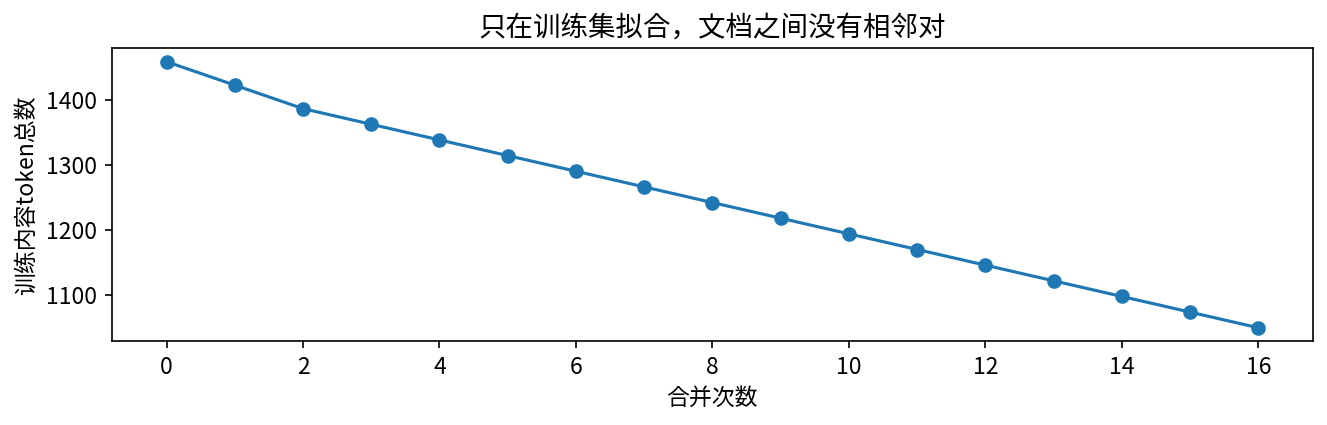

In [2]:
data=json.loads((root/'data/corpus.json').read_text());retained=json.loads((root/'outputs/results.json').read_text())
manifest=json.loads((root/'data/data_manifest.json').read_text())
require(hashlib.sha256((root/'data/corpus.json').read_bytes()).hexdigest()==manifest['corpus_sha256'],'数据SHA不符')
byte=ByteBPE();bpe,history=ByteBPE.fit(data['train'],16)
require(bpe.metadata()['merges']==retained['tokenizer_audit']['bpe']['merges'],'合并表不同')
for text in data['probes']:
    require(bpe.decode(bpe.encode(text))==text,'BPE往返失败')
    print(repr(text),{'codepoints':len(text),'bytes':len(text.encode()),'BPE_content':len(bpe.encode(text))-2,'IDs':bpe.encode(text)})
fig,ax=plt.subplots(figsize=(9,3));ax.plot(range(17),[sum(len(t.encode()) for t in data['train'])]+[h['content_tokens_after'] for h in history],'o-');ax.set(xlabel='合并次数',ylabel='训练内容token总数',title='只在训练集拟合，文档之间没有相邻对');fig.tight_layout();show(fig)

## 2 输入/目标位移和补齐不变性
空内容文档仍有一个EOS目标。mask按目标定义；固定padding行不能代替loss mask。

x=
[[1 4 4 5 0]
 [1 5 0 0 0]
 [1 0 0 0 0]]
y=
[[4 4 5 2 0]
 [5 2 0 0 0]
 [2 0 0 0 0]]
mask=
[[1 1 1 1 0]
 [1 1 0 0 0]
 [1 0 0 0 0]]


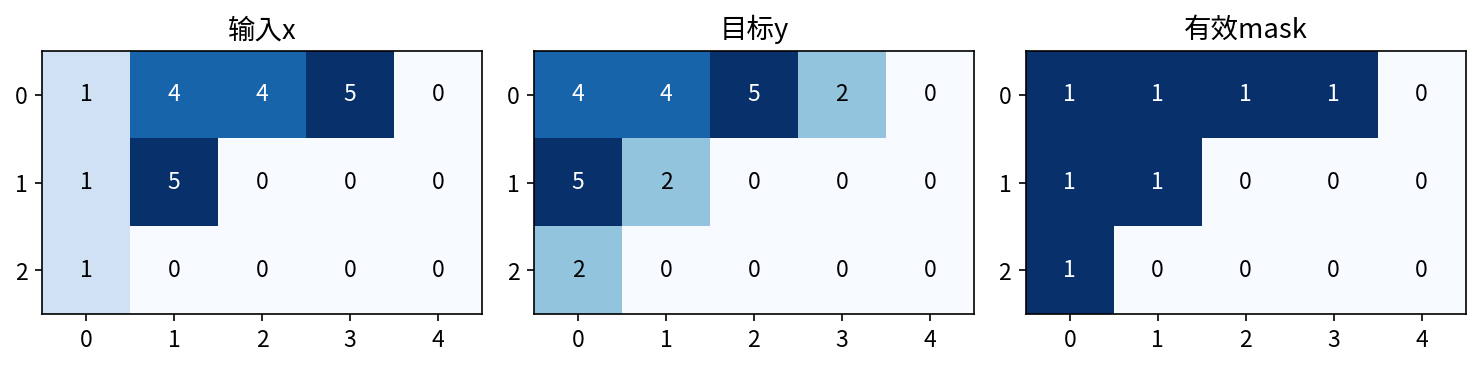

增加右padding后loss和全部梯度相同


In [3]:
x,y,mask,lengths=pad_batch([[1,4,4,5,2],[1,5,2],[1,2]],6,pad_to=5)
require(lengths.tolist()==[4,2,1] and int(mask.sum())==7,'长度/目标错位')
print('x=',x,'y=',y,'mask=',mask.astype(int),sep='\n')
rng=np.random.default_rng(4971);E=rng.normal(0,.1,(6,2));E[0]=0;W=rng.normal(0,.1,(2,6));b=np.zeros(6)
a=pad_batch([[1,4,4,5,2],[1,5,2],[1,2]],6,pad_to=9)
l,g=numpy_objective_gradient(E,W,b,x,y,mask);ll,gg=numpy_objective_gradient(E,W,b,*a[:3]);np.testing.assert_allclose(l,ll,atol=1e-14)
for v,w in zip(g,gg):np.testing.assert_allclose(v,w,atol=1e-14)
fig,axs=plt.subplots(1,3,figsize=(10,2.5))
for ax,v,title in zip(axs,[x,y,mask.astype(int)],['输入x','目标y','有效mask']):
    ax.imshow(v,cmap='Blues',vmin=0,vmax=5 if title!='有效mask' else 1);ax.set_title(title);ax.set_xticks(range(5));ax.set_yticks(range(3))
    for ij in np.ndindex(v.shape):ax.text(ij[1],ij[0],str(v[ij]),ha='center',va='center',color='white' if v[ij]>(2.5 if title!='有效mask' else .5) else 'black')
fig.tight_layout();show(fig);print('增加右padding后loss和全部梯度相同')

## 3 同一手算实例的完整反向与两次更新
每个样本贡献已经包含批次平均。重复ID按位置累加，再跨样本累加。第二次前向必须用更新后的嵌入和头。

state 0 theta [0.0, 0.2, 0.4, 0.3, 0.5, -0.25, 2.0, 0.1] prediction [0.6, -0.4] gradient [0.0, 0.0, 0.0, 0.0, -0.26666666666666666, -0.5333333333333333, 0.0, -0.4] loss 0.08000000000000002
state 1 theta [0.0, 0.2, 0.4, 0.3, 0.5266666666666666, -0.19666666666666666, 2.0, 0.14] prediction [0.711111111111111, -0.2533333333333333] gradient [0.0, 0.0, 0.0, 0.0, -0.19259259259259265, -0.3496296296296296, -0.01633580246913581, -0.27111111111111114] loss 0.03690864197530865
state 2 theta [0.0, 0.2, 0.4, 0.3, 0.5459259259259259, -0.1617037037037037, 2.0016335802469136, 0.1671111111111111] prediction [0.7877163670903825, -0.15656045227251947] gradient [0.0, 0.0, 0.0, 0.0, -0.14163801605623308, -0.22750733733177614, -0.020251002179176997, -0.18442204259106848] loss 0.01739387900427027


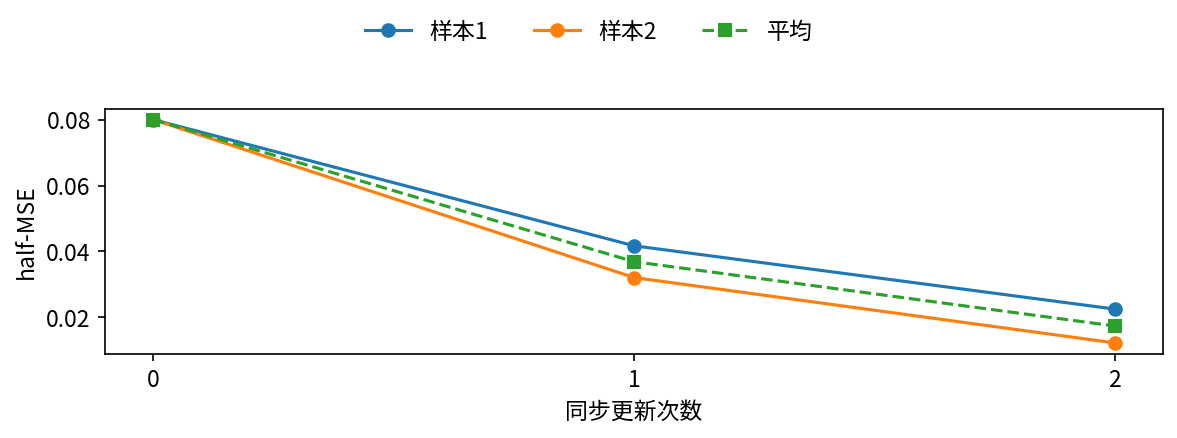

In [4]:
hand=hand_ledger();ids=torch.tensor([[4,4,5],[5,0,0]]);m=(ids!=0).to(torch.float64);target=torch.tensor([1.,0.],dtype=torch.float64)
for state in hand:
    theta=np.array([v['float'] for v in state['theta']]);et=torch.tensor(theta[:6,None],requires_grad=True);wt=torch.tensor(theta[6],requires_grad=True);bt=torch.tensor(theta[7],requires_grad=True)
    hidden=torch.nn.functional.embedding(ids,et,padding_idx=0)[...,0];pooled=(hidden*m).sum(1)/m.sum(1);prediction=pooled*wt+bt;loss=((prediction-target)**2).mean()/2;loss.backward()
    got=np.r_[et.grad.numpy().ravel(),wt.grad.numpy(),bt.grad.numpy()];expected=np.array([v['float'] for v in state['gradient']]);np.testing.assert_allclose(got,expected,atol=2e-14)
    print('state',state['step'],'theta',theta.tolist(),'prediction',prediction.detach().tolist(),'gradient',got.tolist(),'loss',float(loss.detach()))
fig,ax=plt.subplots(figsize=(8,3))
for i in range(2):ax.plot(range(3),[v['samples'][i]['loss']['float'] for v in hand],'o-',label=f'样本{i+1}')
ax.plot(range(3),[v['loss']['float'] for v in hand],'s--',label='平均');ax.set(xlabel='同步更新次数',ylabel='half-MSE',xticks=[0,1,2]);fig.legend(*ax.get_legend_handles_labels(),loc='upper center',ncol=3,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)

## 4 正式契约测试与完整六模型重跑
测试用显式unittest断言，即使python -O也不会被删掉。run先完成训练与序列化再写结果；新输出只放临时目录。跨版本不保证逐字节复现，应先核环境再解释差异。

In [5]:
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
test_result=unittest.TextTestRunner(verbosity=1,stream=sys.stdout).run(suite)
require(test_result.wasSuccessful(),'单元测试失败')
with tempfile.TemporaryDirectory(prefix='dl049-replay-') as folder:
    fresh=run(Path(folder))
    for name in ['results.json','training_traces.json.gz','final_states.json.gz']:
        require((Path(folder)/name).read_bytes()==(root/'outputs'/name).read_bytes(),name+'非原字节复现，请先查环境')
require(len(fresh['runs'])==6,'模型缺失')
print('六模型×120更新完整重跑成功；726参数状态及全部输出原字节复现')
print(json.dumps(fresh['summary'],ensure_ascii=False,indent=2))

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 11 tests in 0.151s

OK


六模型×120更新完整重跑成功；726参数状态及全部输出原字节复现
{
  "byte": {
    "mean_nll_per_target": 4.518608442585646,
    "token_perplexity": 91.71421730577809,
    "bits_per_utf8_byte": 6.733296424445665
  },
  "byte_bpe": {
    "mean_nll_per_target": 4.837269301681948,
    "token_perplexity": 126.14091054054863,
    "bits_per_utf8_byte": 5.296167473796513
  }
}


## 5 用最终权重独立复算测试NLL
逐文档逐相邻ID对计算，不调用训练metrics函数。分母内容730字节，EOS仍计入分子；这个量是确定编码路径成本，不是所有分词路径概率的求和。

In [6]:
states=json.loads(gzip.decompress((root/'outputs/final_states.json.gz').read_bytes()));independent=[]
for state in states:
    tok=bpe if state['kind']=='byte_bpe' else byte;E=np.array(state['E']);W=np.array(state['W']);b=np.array(state['b']);per_doc=[]
    for text in data['test']:
        seq=tok.encode(text);cost=0.
        for a,target in zip(seq,seq[1:]):
            z=E[a]@W+b;shift=z-z.max();cost+=np.log(np.exp(shift).sum())-shift[target]
        per_doc.append(cost)
    record=next(v for v in fresh['runs'] if (v['kind'],v['seed'])==(state['kind'],state['seed']))['metrics']['test']
    np.testing.assert_allclose(per_doc,record['per_document_nll'],atol=1e-10,rtol=1e-12)
    bpb=sum(per_doc)/(sum(len(t.encode()) for t in data['test'])*math.log(2));independent.append(bpb)
    print(state['kind'],state['seed'],'NLL=',sum(per_doc),'bits/byte=',bpb)
print('全部6×24篇测试NLL独立复算通过')

byte 4911 NLL= 3404.1535289617595 bits/byte= 6.727610157065472
byte 4912 NLL= 3419.0150004322813 bits/byte= 6.756980802532369
byte 4913 NLL= 3397.9237677346937 bits/byte= 6.715298313739157
byte_bpe 4911 NLL= 2685.549359597521 bits/byte= 5.307436634457363
byte_bpe 4912 NLL= 2667.195066494052 bits/byte= 5.27116314454038
byte_bpe 4913 NLL= 2686.797153303826 bits/byte= 5.309902642391799
全部6×24篇测试NLL独立复算通过


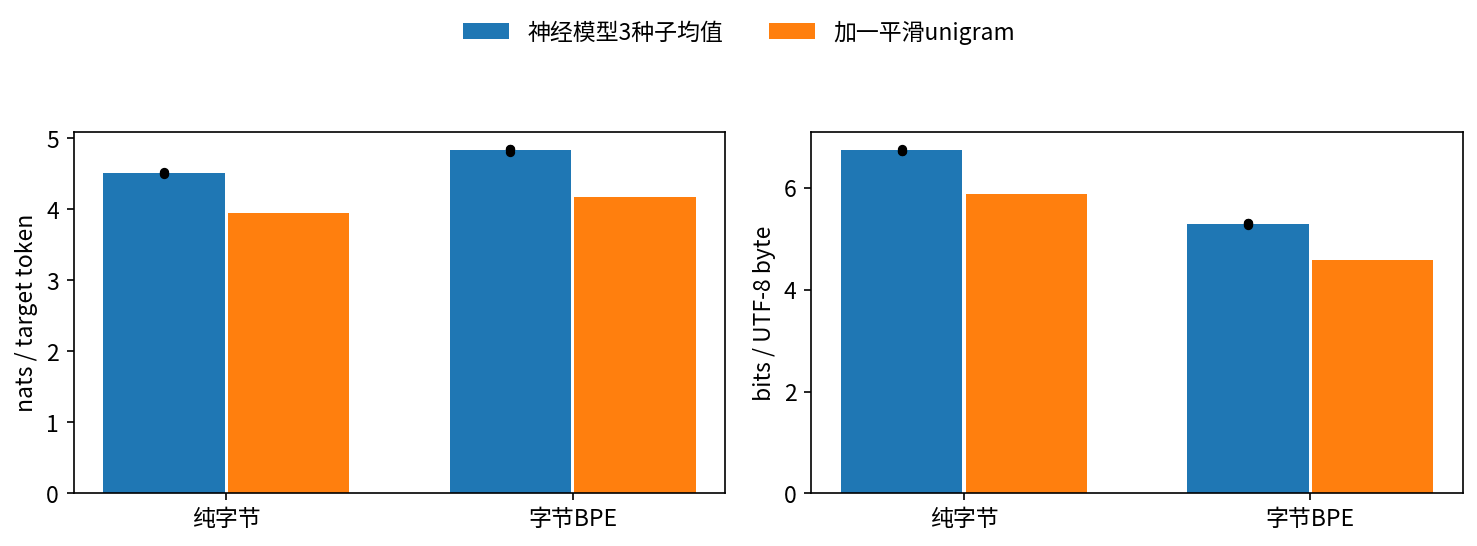

负面结果：本次两种神经配方都没有超过各自unigram基线。词表不同，不直接比较token PPL。


In [7]:
fig,axs=plt.subplots(1,2,figsize=(10,3.7));kinds=['byte','byte_bpe'];x=np.arange(2)
for ax,key,label in zip(axs,['mean_nll_per_target','bits_per_utf8_byte'],['nats / target token','bits / UTF-8 byte']):
    model=[fresh['summary'][k][key] for k in kinds];base=[fresh['unigram_baselines'][k]['metrics']['test'][key] for k in kinds]
    ax.bar(x-.18,model,.35,label='神经模型3种子均值');ax.bar(x+.18,base,.35,label='加一平滑unigram');ax.set_xticks(x,['纯字节','字节BPE']);ax.set_ylabel(label)
    for i,k in enumerate(kinds):ax.scatter([i-.18]*3,[v['metrics']['test'][key] for v in fresh['runs'] if v['kind']==k],color='black',s=12)
fig.legend(*axs[0].get_legend_handles_labels(),loc='upper center',ncol=2,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)
print('负面结果：本次两种神经配方都没有超过各自unigram基线。词表不同，不直接比较token PPL。')

## 继续研究之前
先冻结新问题、数据拆分和预算，再尝试更多合并、长训练或050的RNN。不能将原实验的负面结果删掉。正文、实验指导和答案分别说明合理输入域、失败行为和评价限制。